In [1]:
import icechunk
import xarray as xr
from srm import catalog
import duckdb
import geopandas as gpd
import rasterix
from rasterix.rasterize.rasterio import geometry_mask, geometry_clip
import matplotlib.pyplot as plt
import fsspec
# import matplotlib.style as mplstyle
# mplstyle.use('fast')

# Get data

In [2]:
var_cesm = "TREFHT"
var_era5 = "2m_temperature"
unit_conv_cesm_to_era5 = 1

# var_cesm = 'PRECT'
# var_era5='mean_total_precipitation_rate'
# unit_conv_cesm_to_era5=1000

In [3]:
def fix_coords(ds: xr.Dataset):
    ds.coords["lon"] = (ds.coords["lon"] + 180) % 360 - 180
    ds = ds.sortby(ssp245.lon)
    return ds

In [4]:
ssp245_cat = catalog.get("CESM2-WACCM-SSP245-icechunk")

ssp245_storage = icechunk.s3_storage(
    bucket=ssp245_cat.bucket,
    prefix=ssp245_cat.prefix,
    from_env=True,
)
ssp245_repo = icechunk.Repository.open(ssp245_storage)
ssp245_session = ssp245_repo.readonly_session("main")
ssp245 = xr.open_zarr(ssp245_session.store, consolidated=False)
ssp245 = fix_coords(ssp245)
# ssp245 = rasterix.assign_index(ssp245, x_dim='lon',y_dim='lat')
ssp245 = ssp245.proj.assign_crs(spatial_ref="epsg:4326")

# ssp245

In [5]:
g61pt5k_cat = catalog.get("CESM-G6-1.5K-icechunk")

g61pt5k_storage = icechunk.s3_storage(
    bucket=g61pt5k_cat.bucket,
    prefix=g61pt5k_cat.prefix,
    from_env=True,
)
g61pt5k_repo = icechunk.Repository.open(g61pt5k_storage)
g61pt5k_session = g61pt5k_repo.readonly_session("main")
g61pt5k = xr.open_zarr(g61pt5k_session.store, consolidated=False)
g61pt5k = fix_coords(g61pt5k)

In [6]:
# Temporary until we have these in the catalog


fs = fsspec.filesystem("s3", anon=True)
files = fs.glob(
    "s3://carbonplan-srm/input/tensor/CESM2-WACCM-Historical/netcdf/*.h1.TREFHT.*.nc"
)
open_files = [fs.open(file, mode="rb") for file in files]
model_historical = xr.open_mfdataset(
    open_files, engine="h5netcdf", combine="by_coords", parallel=True
)

model_historical = model_historical.unify_chunks()
model_historical = model_historical.proj.assign_crs(spatial_ref="epsg:4326")

/tmp/ipykernel_221/1593096879.py:9: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  model_historical = xr.open_mfdataset(


In [7]:
era5_cat = catalog.get("ERA5")
era5_storage = icechunk.s3_storage(
    bucket=era5_cat.bucket,
    prefix=era5_cat.prefix,
    from_env=True,
)
era5_repo = icechunk.Repository.open(era5_storage)
era5_session = era5_repo.readonly_session("main")
era5 = xr.open_zarr(era5_session.store).pipe(rasterix.assign_index)
era5 = era5.proj.assign_crs(spatial_ref="epsg:4326")

In [8]:
df = duckdb.sql(
    """install httpfs; load httpfs; install spatial; load spatial; SELECT name, ST_AsText(geom) as geometry FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json') WHERE NAME = 'South Africa'"""
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
south_africa_geom = gpd.GeoDataFrame(df, geometry="geometry")

lon_min, lat_min, lon_max, lat_max = south_africa_geom.total_bounds
lon_min = lon_min - 2
lon_max = lon_max + 2
lat_min = lat_min - 2
lat_max = lat_max + 2

In [9]:
cities = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip",
    columns=["name", "sov0name", "geometry"],
)
sa_cities = cities[cities["sov0name"] == "South Africa"]
cape_town_x, cape_town_y = (
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x),
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y),
)

/tmp/ipykernel_221/1595652233.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x),
/tmp/ipykernel_221/1595652233.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y),


# Subset data to demo region (South Africa)

In [10]:
era5_south_africa = geometry_clip(
    era5, south_africa_geom[["geometry"]], xdim="longitude", ydim="latitude"
)

era5_south_africa_bounds = era5.sel(
    longitude=slice(lon_min, lon_max),
    latitude=slice(lat_max, lat_min),  # Note: descending order for latitude
)

In [11]:
ssp245_south_africa_bounds = ssp245.sortby("lat", ascending=False).sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_max, lat_min),  # Note: descending order for latitude
)

ssp245_south_africa = geometry_clip(
    ssp245.sortby("lat", ascending=False),
    south_africa_geom[["geometry"]],
    xdim="lon",
    ydim="lat",
)

In [12]:
g61pt5k_south_africa_bounds = g61pt5k.sortby("lat", ascending=False).sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_max, lat_min),  # Note: descending order for latitude
)

g61pt5k_south_africa = geometry_clip(
    g61pt5k.sortby("lat", ascending=False),
    south_africa_geom[["geometry"]],
    xdim="lon",
    ydim="lat",
)

In [ ]:
model_historical_south_africa_bounds = (
    model_historical.sortby("lat", ascending=False)
    .sel(
        lon=slice(lon_min, lon_max),
        lat=slice(lat_max, lat_min),  # Note: descending order for latitude
    )
    .load()
)

model_historical_south_africa = geometry_clip(
    model_historical.sortby("lat", ascending=False),
    south_africa_geom[["geometry"]],
    xdim="lon",
    ydim="lat",
).load()

# Figures of raw data

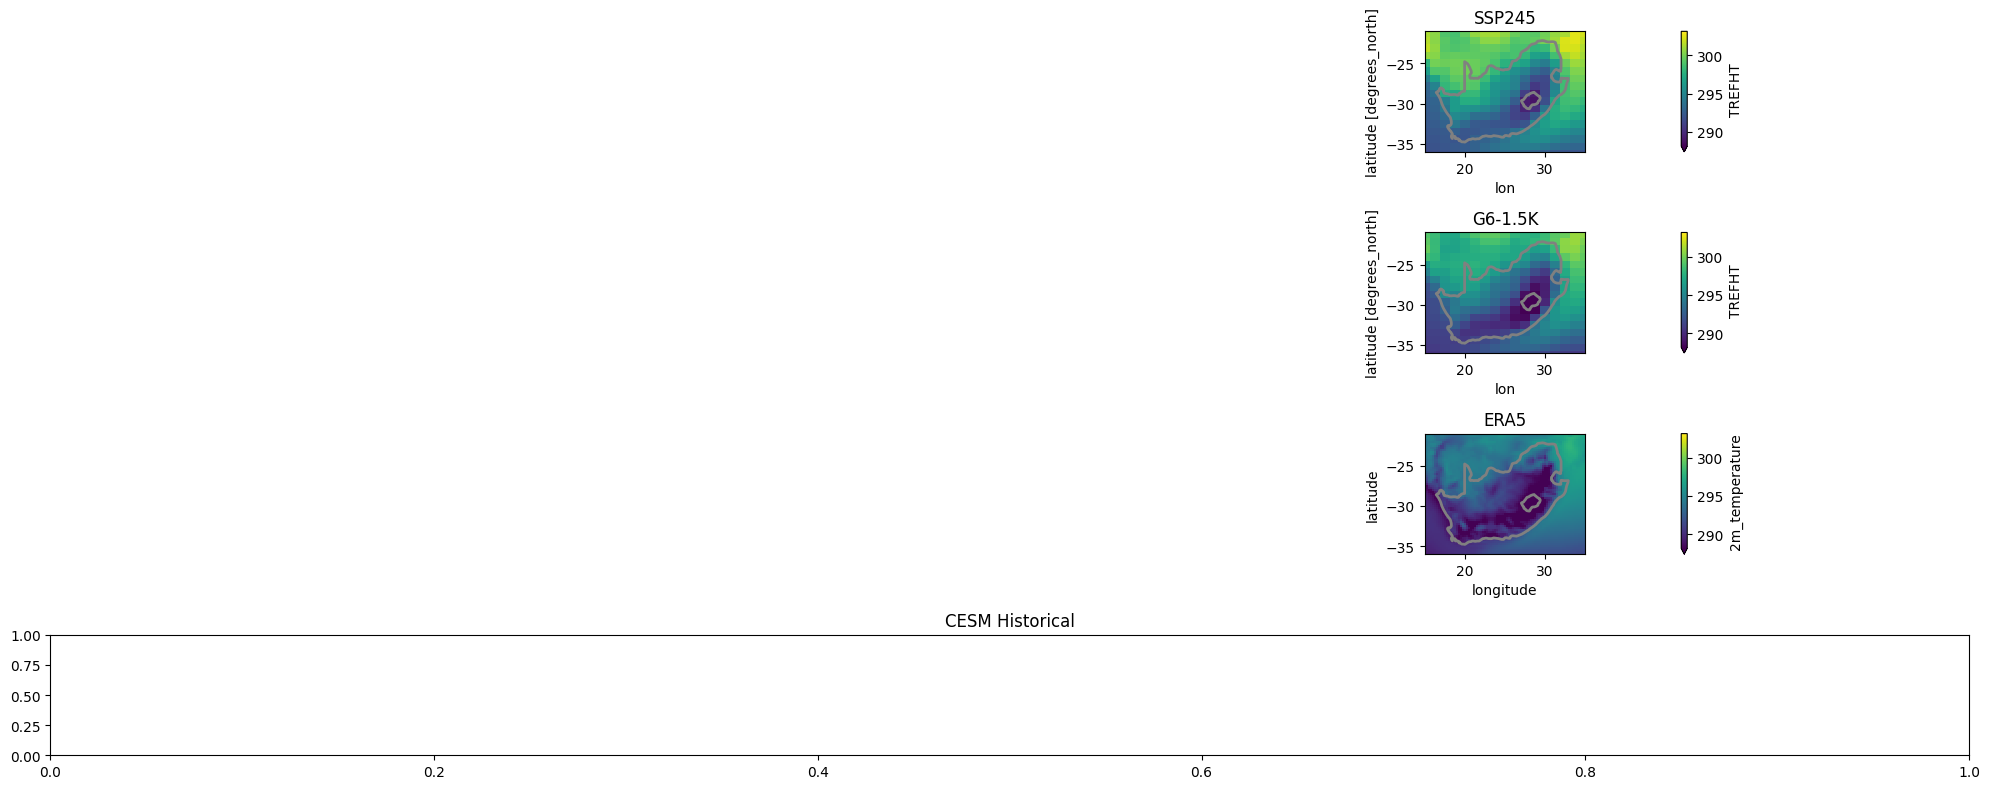

In [ ]:
fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(20, 8))
vmin = 15 + 273.15  # 0 #15+273.15
vmax = 30 + 273.15  # 5.5e-5 #30+273.15

(
    (ssp245_south_africa_bounds[var_cesm] * unit_conv_cesm_to_era5)
    .sel(time=ssp245_south_africa_bounds.time.dt.year >= 2090)
    .mean(dim="time")
).plot(ax=ax[0], add_colorbar=True, vmin=vmin, vmax=vmax)
south_africa_geom["geometry"].plot(
    ax=ax[0], facecolor="none", edgecolor="gray", linewidth=2
)
ax[0].set_title("SSP245")
ax[0].set_xlim([15, 35])
ax[0].set_ylim([-36, -21])

(
    (g61pt5k_south_africa_bounds[var_cesm] * unit_conv_cesm_to_era5)
    .sel(time=g61pt5k_south_africa_bounds.time.dt.year >= 2070)
    .mean(dim="time")
).plot(ax=ax[1], add_colorbar=True, vmin=vmin, vmax=vmax)
south_africa_geom["geometry"].plot(
    ax=ax[1], facecolor="none", edgecolor="gray", linewidth=2
)
ax[1].set_title("G6-1.5K")
ax[1].set_xlim([15, 35])
ax[1].set_ylim([-36, -21])

((era5_south_africa_bounds[var_era5]).mean(dim="time")).plot(
    ax=ax[2], add_colorbar=True, vmin=vmin, vmax=vmax
)
south_africa_geom["geometry"].plot(
    ax=ax[2], facecolor="none", edgecolor="gray", linewidth=2
)
ax[2].set_title("ERA5")
ax[2].set_xlim([15, 35])
ax[2].set_ylim([-36, -21])
plt.tight_layout()

# ((model_historical_south_africa_bounds[var_cesm]*unit_conv_cesm_to_era5).mean(dim='time')).plot(ax=ax[3], add_colorbar=True, vmin=vmin, vmax=vmax)
# south_africa_geom["geometry"].plot(ax=ax[3], facecolor="none", edgecolor="gray", linewidth=2)
ax[3].set_title("CESM Historical")
# ax[3].set_xlim([15,35])
# ax[3].set_ylim([-36,-21])
plt.tight_layout()
plt.show()

In [ ]:
era5_CT_tseries = era5_south_africa_bounds.sel(
    latitude=cape_town_y, longitude=cape_town_x, method="nearest"
)
ssp245_CT_tseries = ssp245_south_africa_bounds.sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
)

g61pt5k_CT_tseries = g61pt5k_south_africa_bounds.sel(
    lat=cape_town_y, lon=cape_town_x, method="nearest"
)

# model_historical_CT_tseries = model_historical_south_africa_bounds.sel(
#    lat=cape_town_y, lon=cape_town_x, method="nearest"
# )

In [ ]:
ssp245_CT_tseries = ssp245_CT_tseries.convert_calendar("standard", use_cftime=False)
g61pt5k_CT_tseries = g61pt5k_CT_tseries.convert_calendar("standard", use_cftime=False)

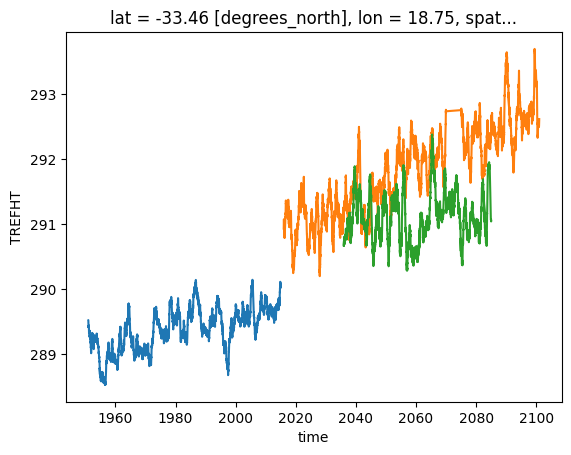

In [ ]:
era5_CT_tseries[var_era5].rolling(time=365).mean().plot(label="Historical (ERA5)")
# model_historical_CT_tseries[var_era5].rolling(time=365).mean().plot(label='Historical (CESM2)')
(ssp245_CT_tseries[var_cesm] * unit_conv_cesm_to_era5).rolling(time=365).mean().plot(
    label="SSP245 (CESM2)"
)
(g61pt5k_CT_tseries[var_cesm] * unit_conv_cesm_to_era5).rolling(time=365).mean().plot(
    label="G6-1.5K (CESM2)"
)

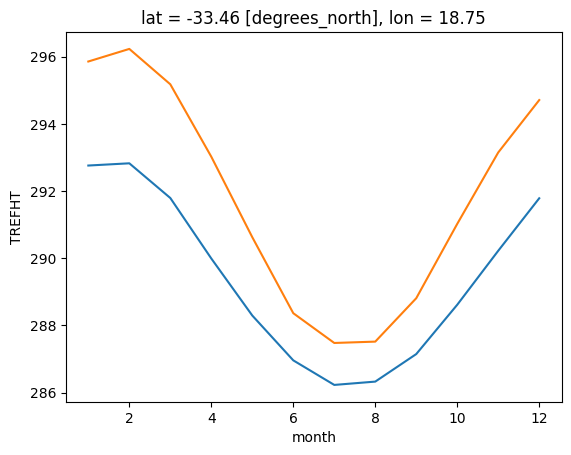

In [ ]:
da = era5_CT_tseries[var_era5].drop_vars("spatial_ref", errors="ignore")
era5_monthly_mean = da.groupby("time.month").mean(dim="time")

da = (ssp245_CT_tseries[var_cesm] * unit_conv_cesm_to_era5).drop_vars(
    "spatial_ref", errors="ignore"
)
ssp245_monthly_mean = da.groupby("time.month").mean(dim="time")

era5_monthly_mean.plot()
ssp245_monthly_mean.plot()

(array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.00010971, 0.00021942, 0.00208448,
        0.00493692, 0.01195831, 0.02512342, 0.03642348, 0.05704882,
        0.07427318, 0.08842567, 0.08908393, 0.08886451, 0.08392759,
        0.07778387, 0.07723533, 0.07284696, 0.07526056, 0.07526056,
        0.07712562, 0.08063631, 0.07855184, 0.08579265, 0.0828305 ,
        0.08919364, 0.08579265, 0.08315963, 0.07120132, 0.06494789,
        0.05222161, 0.04410313, 0.03828854, 0.03027976, 0.02347778,
        0.0177729 , 0.01316511, 0.01020296, 0.00866703, 0.00778936,
        0.00515634, 0.00438837, 0.00230389, 0.00208448]),
 array([273.15, 273.65, 274.15, 274.65, 275.15, 275.65, 276.15, 276.65,
        277.15, 277.65, 278.15, 278.65, 279.15, 279.65, 280.15, 280.65,
        281.15, 281.65, 282.15, 282.65, 283.15, 28

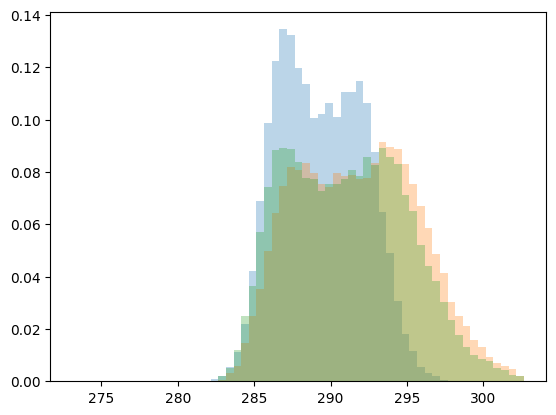

In [ ]:
import numpy as np

plt.hist(
    era5_CT_tseries[var_era5],
    bins=np.arange(0, 30, 0.5) + 273.15,
    density=True,
    alpha=0.3,
)
plt.hist(
    (ssp245_CT_tseries[var_cesm] * unit_conv_cesm_to_era5),
    bins=np.arange(0, 30, 0.5) + 273.15,
    density=True,
    alpha=0.3,
)
# plt.hist((model_historical_CT_tseries[var_cesm]*unit_conv_cesm_to_era5), bins=np.arange(0,30,0.5)+273.15, density=True, alpha=0.3)
plt.hist(
    (g61pt5k_CT_tseries[var_cesm] * unit_conv_cesm_to_era5),
    bins=np.arange(0, 30, 0.5) + 273.15,
    density=True,
    alpha=0.3,
)

# Bias correct

### Prep data

In [ ]:
era5_south_africa_bounds_coarse = era5_south_africa_bounds.interp(
    longitude=ssp245_south_africa_bounds.lon,
    latitude=ssp245_south_africa_bounds.lat,
    method="linear",
)

In [39]:
tas_obs = era5_south_africa_bounds_coarse['2m_temperature'].values
time_obs = era5_south_africa_bounds_coarse['time'].values
tas_cm_hist = ssp245_south_africa_bounds['TREFHT'].values
time_cm_hist = ssp245_south_africa_bounds['time'].values
tas_cm_future = 
time_cm_future = 

In [ ]:
split_ratio = 0.7
split = int(split_ratio * tas_obs.shape[0])

# First split observations
tas_obs_train = tas_obs[:split]
tas_obs_val = tas_obs[split:]
time_obs_train = time_obs[:split]
time_obs_val = time_obs[split:]

# Then split cm_hist
tas_cm_hist_train = tas_cm_hist[:split]
tas_cm_hist_val = tas_cm_hist[split:]
time_cm_hist_train = time_cm_hist[:split]
time_cm_hist_val = time_cm_hist[split:]

### Initialize the bias adjustment method and apply the bias adjustment method on the validation period

In [33]:
from ibicus.debias import LinearScaling, ISIMIP

debiaser = ISIMIP.from_variable(variable = 'tas')

In [ ]:
# Option 1: no parallelization
# This version takes about an hour on m8g.2xlarge with no parallelization
tas_val_debiased_ISIMIP = debiaser.apply(
    tas_obs_train,
    tas_cm_hist_train,
    tas_cm_hist_val,
    time_obs=time_obs_train,
    time_cm_hist=time_cm_hist_train,
    time_cm_future=time_cm_hist_val,
)

100%|██████████| 620/620 [57:43<00:00,  5.59s/it]


In [ ]:
# Option 2: parallelize with dask

import dask.array as da

collection = da.map_blocks(
    debiaser.apply,
    tas_obs_train,
    tas_cm_hist_train,
    tas_cm_hist_val,
    time_obs=time_obs_train,
    time_cm_hist=time_cm_hist_train,
    time_cm_future=time_cm_hist_val,
    dtype=tas_obs_train.dtype,
    progressbar=False,
    parallel=False,
)
debiased_cm_hist = collection.compute(num_workers=8)

### Evaluate the bias corrected climate model on the validation period

/opt/coiled/env/lib/python3.13/site-packages/ibicus/evaluate/marginal.py:94: RuntimeWarning: invalid value encountered in divide
  bias = 100 * (cm_metric - obs_metric) / obs_metric
/opt/coiled/env/lib/python3.13/site-packages/ibicus/evaluate/marginal.py:94: RuntimeWarning: divide by zero encountered in divide
  bias = 100 * (cm_metric - obs_metric) / obs_metric
/tmp/ipykernel_11350/3544644140.py:4: UserWarning: ISIMIP: Division by zero encountered in bias of ThresholdMetric(threshold_value=283, threshold_type='lower', threshold_scope='overall', threshold_locality='global', name='Mean cold days (K)', variable='tas') calculation, not showing results for this debiaser.
  tas_marginal_bias_data = marginal.calculate_marginal_bias(metrics = [cold_days], obs = tas_obs_val,


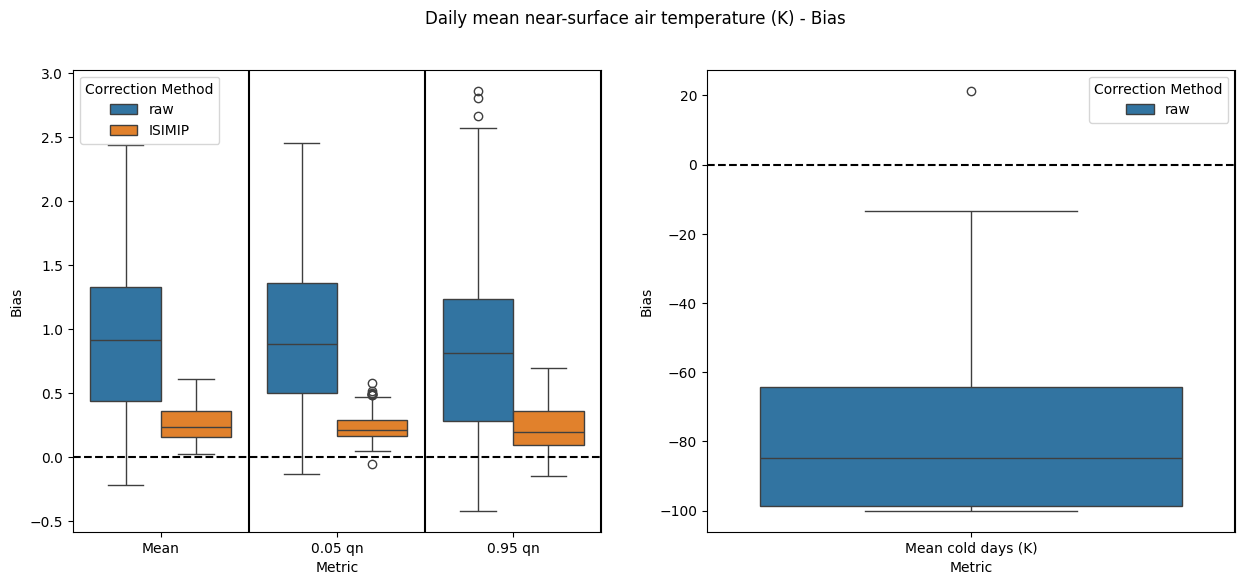

In [ ]:
from ibicus.evaluate.metrics import warm_days

warm_days.threshold_value = 273.15 + 30
from ibicus.evaluate import marginal

tas_marginal_bias_data = marginal.calculate_marginal_bias(
    metrics=[cold_days],
    obs=tas_obs_val,
    raw=tas_cm_hist_val,
    ISIMIP=tas_val_debiased_ISIMIP,
)

plot = marginal.plot_marginal_bias(variable="tas", bias_df=tas_marginal_bias_data)
plot.show()

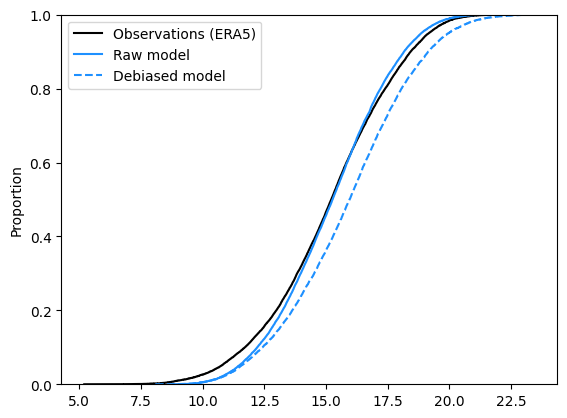

In [ ]:
import seaborn as sns

sns.ecdfplot(tas_obs_train[:, 20, 10] - 273.15, label="Observations (ERA5)", color="k")
sns.ecdfplot(
    tas_cm_hist_train[:, 20, 10] - 273.15, label="Raw model", color="dodgerblue"
)
sns.ecdfplot(
    tas_val_debiased_ISIMIP[:, 20, 10] - 273.15,
    label="Debiased model",
    color="dodgerblue",
    linestyle="--",
)
plt.legend()

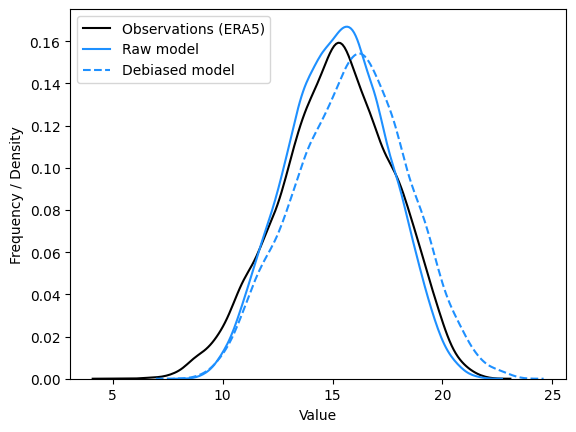

In [ ]:
sns.kdeplot(tas_obs_train[:, 20, 10] - 273.15, label="Observations (ERA5)", color="k")
sns.kdeplot(
    tas_cm_hist_train[:, 20, 10] - 273.15, label="Raw model", color="dodgerblue"
)
sns.kdeplot(
    tas_val_debiased_ISIMIP[:, 20, 10] - 273.15,
    label="Debiased model",
    color="dodgerblue",
    linestyle="--",
)
plt.xlabel("Value")
plt.ylabel("Frequency / Density")
plt.legend()
plt.show()

### Apply the debiaser to the future

In [ ]:
tas_fut_debiased_ISIMIP = tas_debiaser_ISIMIP.apply(
    tas_obs,
    tas_cm_hist,
    tas_cm_future,
    time_obs=time_obs,
    time_cm_hist=time_cm_hist,
    time_cm_future=time_cm_future,
)

array([290.73334, 292.90463, 295.41357, ..., 285.6936 , 285.8158 ,
       285.5905 ], shape=(16618,), dtype=float32)